In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/mscoco


/content/drive/MyDrive/mscoco


In [ ]:
# CELL 1: Check if coco-tasks actually has the annotation files
!ls /content/drive/MyDrive/mscoco/coco-tasks/
!ls /content/drive/MyDrive/mscoco/coco-tasks/annotations/

annotations		detections_yolo.json  LICENSE  README.md	 TB
detections_faster.json	image_lists	      pairs    saving_directory
task_10_test.json   task_13_train.json	task_3_test.json   task_6_train.json
task_10_train.json  task_14_test.json	task_3_train.json  task_7_test.json
task_11_test.json   task_14_train.json	task_4_test.json   task_7_train.json
task_11_train.json  task_1_test.json	task_4_train.json  task_8_test.json
task_12_test.json   task_1_train.json	task_5_test.json   task_8_train.json
task_12_train.json  task_2_test.json	task_5_train.json  task_9_test.json
task_13_test.json   task_2_train.json	task_6_test.json   task_9_train.json


In [ ]:
import sys
import os

# Add the 'src' folder to the python path
src_path = '/content/drive/My Drive/task-driven-object-detection/src'
sys.path.append(src_path)

# Change directory to src so relative paths work
os.chdir(src_path)

In [ ]:
pip install ultralytics

In [ ]:
import sys, importlib, torch

project_src = '/content/drive/My Drive/task-driven-object-detection/src'
if project_src not in sys.path:
    sys.path.append(project_src)

import yolo_feature_extractor
importlib.reload(yolo_feature_extractor)
from yolo_feature_extractor import YOLOFeatureExtractor

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_custom = YOLOFeatureExtractor(
    weights_path='/content/drive/My Drive/yolo26n.pt',
    conf_thresh=0.1,
    hook_indices={'P3':16, 'P4':19, 'P5':22}
).to(device)

model_custom.eval()   # now safe
print("Eval mode set safely.")

[INFO] Loaded YOLO26n weights from: /content/drive/My Drive/yolo26n.pt
[INFO] Hook registered: P3 ← model.model[16]
[INFO] Hook registered: P4 ← model.model[19]
[INFO] Hook registered: P5 ← model.model[22]
Eval mode set safely.


In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics.data.augment import LetterBox

from yolo_feature_extractor import YOLOFeatureExtractor

device = "cuda" if torch.cuda.is_available() else "cpu"
weights_path = "/content/drive/My Drive/yolo26n.pt"

model_custom = YOLOFeatureExtractor(
    weights_path=weights_path,
    conf_thresh=0.1,
    hook_indices={"P3": 16, "P4": 19, "P5": 22}
).to(device)

model_custom.eval()
print("Device:", device)
print("Model loaded.")

[INFO] Loaded YOLO26n weights from: /content/drive/My Drive/yolo26n.pt
[INFO] Hook registered: P3 ← model.model[16]
[INFO] Hook registered: P4 ← model.model[19]
[INFO] Hook registered: P5 ← model.model[22]
Device: cuda
Model loaded.


In [ ]:
# Single inference path (do NOT mix with separate YOLO(...) model calls)

img_path = "/content/drive/My Drive/mscoco/val2014/COCO_val2014_000000000042.jpg"
raw_img = Image.open(img_path).convert("RGB")

# Keep one preprocessing method only
letterbox = LetterBox(new_shape=(640, 640), auto=False)
img_np = np.array(raw_img)
img_padded = letterbox(image=img_np)

img_tensor = torch.from_numpy(img_padded).permute(2, 0, 1).float() / 255.0
img_tensor = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    output = model_custom(img_tensor)

# Tensor outputs
p3 = output["feature_maps"]["P3"]
p4 = output["feature_maps"]["P4"]
p5 = output["feature_maps"]["P5"]
phi_o = output["visual_fingerprints"]
det = output["detections"][0]

print("P3:", tuple(p3.shape))
print("P4:", tuple(p4.shape))
print("P5:", tuple(p5.shape))
print("phi_o:", tuple(phi_o.shape))
print("Detected objects:", len(det["boxes"]))

P3: (1, 64, 80, 80)
P4: (1, 128, 40, 40)
P5: (1, 256, 20, 20)
phi_o: (2, 128)
Detected objects: 2


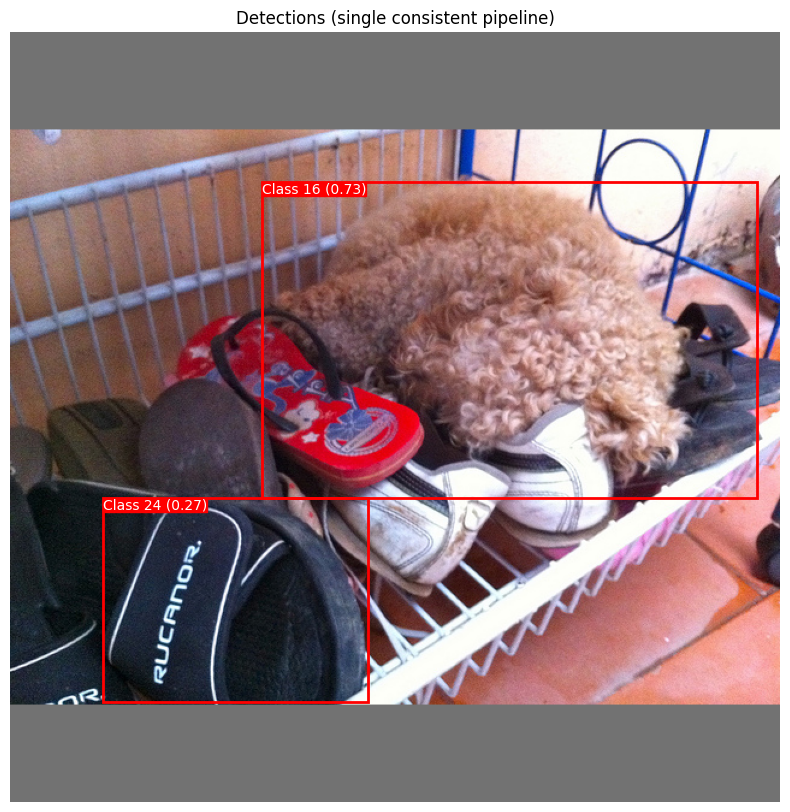

In [ ]:
# Visualize detections from the SAME output
boxes = det["boxes"].detach().cpu().numpy()
scores = det["scores"].detach().cpu().numpy()
classes = det["classes"].detach().cpu().numpy()

fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(Image.fromarray(img_padded))

for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes[i]
    w, h = x2 - x1, y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="r", facecolor="none")
    ax.add_patch(rect)
    ax.text(
        x1, y1,
        f"Class {int(classes[i])} ({scores[i]:.2f})",
        color="white",
        verticalalignment="top",
        bbox={"color": "red", "pad": 0}
    )

ax.axis("off")
ax.set_title("Detections (single consistent pipeline)")
plt.show()

In [ ]:
# ensure class-name mapping exists (fallback to COCO 80 names)
try:
    COCO_CLASSES
except NameError:
    COCO_CLASSES = [
        'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat','traffic light',
        'fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow',
        'elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee',
        'skis','snowboard','sports ball','kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle',
        'wine glass','cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange',
        'broccoli','carrot','hot dog','pizza','donut','cake','chair','couch','potted plant','bed',
        'dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven',
        'toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
    ]

In [ ]:
# Draw boxes with torchvision then overlay larger labels with PIL
import torch
from torchvision.utils import draw_bounding_boxes
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# Ensure COCO_CLASSES exists (fallback)
try:
    COCO_CLASSES
except NameError:
    COCO_CLASSES = [ ... ]  # paste your 80-class list here if needed

# img_tensor: [1,3,H,W] (0..1). output: dict returned by model_custom(img_tensor)
img = (img_tensor[0] * 255).to(torch.uint8)            # [3,H,W] uint8
det = output['detections'][0]

boxes = det.get('boxes', torch.zeros((0,4))).cpu()     # [N,4] xyxy
scores = det.get('scores', torch.zeros((boxes.shape[0],))).cpu()
classes = det.get('classes', torch.zeros((boxes.shape[0],), dtype=torch.long)).cpu()

if boxes.numel() == 0:
    print("No detections to draw.")
else:
    # Build human-readable labels
    labels = []
    for cid, s in zip(classes, scores):
        cid = int(cid)
        name = COCO_CLASSES[cid] if 0 <= cid < len(COCO_CLASSES) else str(cid)
        labels.append(f"{name} {float(s):.2f}")

    # draw_bounding_boxes: returns CHW uint8 tensor
    annot = draw_bounding_boxes(img, boxes, labels=None, colors="red", width=3)

    # Convert to PIL for high-quality text rendering
    annot_pil = Image.fromarray(annot.permute(1, 2, 0).cpu().numpy())
    draw = ImageDraw.Draw(annot_pil)

    # Choose font size relative to image height (e.g., 3.5% of H)
    H = annot_pil.height
    font_size = max(12, int(H * 0.035))
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", size=font_size)
    except Exception:
        font = ImageFont.load_default()

    # Overlay labels with larger font and a filled background for readability
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in box.tolist()]
        label = labels[i]
        text_w, text_h = draw.textsize(label, font=font)
        pad = max(4, int(font_size * 0.2))

        # position background above the box if possible, otherwise inside
        bg_x1 = x1
        bg_y1 = max(0, y1 - text_h - pad)
        bg_x2 = x1 + text_w + pad * 2
        bg_y2 = bg_y1 + text_h + pad

        draw.rectangle([bg_x1, bg_y1, bg_x2, bg_y2], fill=(220, 20, 20, 180))
        draw.text((bg_x1 + pad, bg_y1 + (pad // 2)), label, fill="white", font=font)

    display(annot_pil)

AttributeError: 'ImageDraw' object has no attribute 'textsize'